# 011. Boston House Price Regression

## sklearn LinearRegression을 이용한 보스턴 주택가격 예측

### 13개의 특성(Feature)과 1개의 타겟(주택가격 중앙값)으로 구성

#### 특성 (13개)
CRIM 자치시(town) 별 1인당 범죄율  
ZN 25,000 평방피트를 초과하는 거주지역의 비율  
INDUS 비소매상업지역이 점유하고 있는 토지의 비율  
CHAS 찰스강에 대한 더미변수(강의 경계에 위치한 경우는 1, 아니면 0)  
NOX 10ppm 당 농축 일산화질소  
RM 주택 1가구당 평균 방의 개수  
AGE 1940년 이전에 건축된 소유주택의 비율  
DIS 5개의 보스턴 직업센터까지의 접근성 지수  
RAD 방사형 도로까지의 접근성 지수  
TAX 10,000 달러 당 재산세율  
PTRATIO 자치시(town)별 학생/교사 비율  
B 1000(Bk-0.63)^2, 여기서 Bk는 자치시별 흑인의 비율을 말함  
LSTAT 모집단의 하위계층의 비율(%)  

#### 타겟 (1개)
MEDV 본인 소유의 주택가격(중앙값) (단위: $1,000)

필요한 라이브러리를 import 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### 데이터 로드

sklearn의 `load_boston`이 제거되었으므로 원본 데이터를 직접 다운로드합니다.

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"

raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Boston 데이터는 한 샘플이 두 줄에 걸쳐 저장되어 있음
data = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])
target = raw_df.values[1::2, 2]

feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

df_boston = pd.DataFrame(data, columns=feature_names)
df_boston['MEDV'] = target
df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
X = data
y = target
print(f"데이터 크기: {X.shape} (샘플 수, 특성 수)")
print(f"타겟 크기: {y.shape}")

데이터 크기: (506, 13) (샘플 수, 특성 수)
타겟 크기: (506,)


### 데이터 분할

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"훈련 세트: {X_train.shape[0]}개, 테스트 세트: {X_test.shape[0]}개")

훈련 세트: 404개, 테스트 세트: 102개


### 모델 학습 및 예측

In [5]:
# LinearRegression 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

### 평가: R² Score & RMSE

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\qquad\Longrightarrow\qquad
\mathrm{RMSE} = \sqrt{\mathrm{MSE}}
$$

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"MSE:      {mse:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"→ 예측값이 평균적으로 실제값과 약 ${rmse:.1f} × 1,000 정도 차이남")

R² Score: 0.6688
MSE:      24.29
RMSE:     4.93
→ 예측값이 평균적으로 실제값과 약 $4.9 × 1,000 정도 차이남


### 시각화: 실제값 vs 예측값

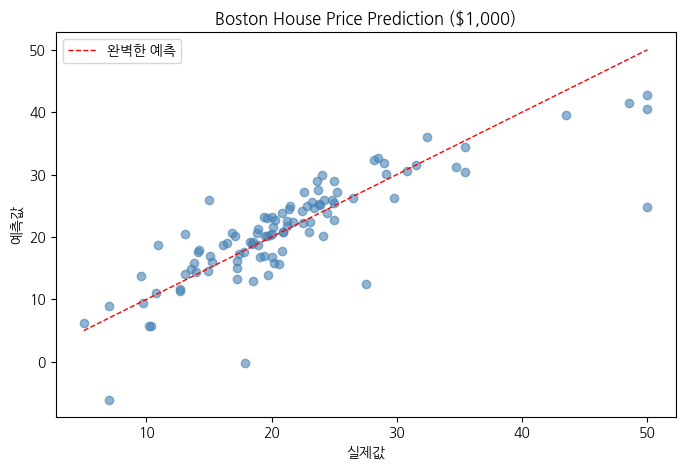

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1, label='완벽한 예측')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('Boston House Price Prediction ($1,000)')
plt.legend()
plt.show()

---
## 실습

### UCI Machine Learning Repository의 Auto MPG dataset을 사용하여 자동차 연비 예측 Regression Model 작성

- auto-mpg.data - data file
- auto-mpg.names - data 설명 file

    1. mpg:           continuous (연비 - 타겟)  
    2. cylinders:     multi-valued discrete  
    3. displacement:  continuous (배기량)  
    4. horsepower:    continuous  
    5. weight:        continuous  
    6. acceleration:  continuous  
    7. model year:    multi-valued discrete  
    8. origin:        multi-valued discrete, 1 - USA, 2 - Europe, 3 - Japan  
    9. car name:      string (unique for each instance)  

Missing Attribute Values: horsepower has 6 missing values ==> "?"로 들어있으므로 read_csv 시 nan으로 변환

### Data Load 및 Preprocessing

In [9]:
data_path = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model year', 'origin'
]

rawdata = pd.read_csv(
    data_path,
    names=column_names,
    na_values="?",
    comment="\t",
    sep=" ",
    skipinitialspace=True
)

rawdata.dropna(inplace=True)
data = rawdata.copy()

# 범주형 변수 원-핫 인코딩
data = pd.get_dummies(data, columns=['cylinders', 'origin'])

# 타겟 분리
label = data.pop('mpg')

X_train, X_test, y_train, y_test = train_test_split(
    data.values, label.values, test_size=0.2, random_state=42
)
print(f"훈련: {X_train.shape}, 테스트: {X_test.shape}")

훈련: (313, 13), 테스트: (79, 13)


### Regression Model Build

In [ ]:
# 여기에 LinearRegression 모델을 작성하세요


### Predict

In [ ]:
# 여기에 예측 코드를 작성하세요


### R² Score & RMSE 계산

In [ ]:
# 여기에 평가 코드를 작성하세요


### 시각화

In [ ]:
# 여기에 시각화 코드를 작성하세요
